# Audio Processing with CNNs and Transfer Learning

By: John Godfrey

-----------------------------------------------

### Load the Data

The first step of the process is to load the Speech Commands dataset directly from tochaudio.

In [1]:
# Load Important Packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch.utils.data import Subset
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
import torch
import torchaudio
import os
import IPython.display as ipd
import torch
from torch.utils.data import DataLoader
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

In [2]:
# Download the Dataset
os.makedirs("./data", exist_ok=True)
dataset = torchaudio.datasets.SPEECHCOMMANDS(root="./data", url="speech_commands_v0.02", download=True)

print(f"\nDataset successfully downloaded! Total samples: {len(dataset)}")


Dataset successfully downloaded! Total samples: 105829


There are 105,829 total samples in the dataset so we will have plenty of data to work with (be careful when training the models because it will take a long time).

Next we will take a look at the first sample in the dataset to get a better idea of what we are working with.

In [3]:
# Inspect first sample
waveform, sample_rate, label, speaker_id, utterance_number = dataset[0]

print(f"Spoken Word (Label): {label}")
print(f"Sampling Rate: {sample_rate} Hz")
print(f"Waveform Shape (Channels, Length): {waveform.shape}")

# You can play the audio directly in the notebook
ipd.Audio(data=waveform.numpy(), rate=sample_rate)


Spoken Word (Label): backward
Sampling Rate: 16000 Hz
Waveform Shape (Channels, Length): torch.Size([1, 16000])


It is a one second clip that says "Backward." Its sampling rate is 16,000 Hz and its shape is 1 x 16,000.

## Preprocessing

Let's start working with preprocessing. We will create the transfromations for STFT, Log-Mel Spectrogram, and MFCC (Mel-Frequency Cepstral Coefficients). We will also plot the transformations to see visually what the transfomrations did.

In [4]:
# Define hyperparameters for our transforms
n_fft = 1024       # Window size for the STFT
hop_length = 512   # How far the window slides over the audio
n_mels = 64        # Number of Mel filterbanks
n_mfcc = 13        # Number of coefficients to keep after the DCT step

# 1. Standard Spectrogram (STFT)
spectrogram_transform = T.Spectrogram(
    n_fft=n_fft,
    hop_length=hop_length,
    power=2.0
)

# 2. Log-Mel Spectrogram
mel_spectrogram_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels
)

# Convert to Decibels (log scale)
db_transform = T.AmplitudeToDB(stype="power", top_db=80)

# 3. MFCC (Mel-Frequency Cepstral Coefficients)
mfcc_transform = T.MFCC(
    sample_rate=sample_rate,
    n_mfcc=n_mfcc,
    melkwargs={
        "n_fft": n_fft,
        "hop_length": hop_length,
        "n_mels": n_mels,
    }
)

In [5]:
# Apply the transformations to our sample waveform
spec = spectrogram_transform(waveform)
spec_db = db_transform(spec)

mel_spec = mel_spectrogram_transform(waveform)
log_mel_spec = db_transform(mel_spec)

mfcc = mfcc_transform(waveform)

# Check transformations worked
print("Original Waveform shape: ", waveform.shape)
print(f"STFT Spectrogram shape: ", spec_db.shape)
print(f"Log Mel Spectrogram shape: ", log_mel_spec.shape)
print(f"MFCC shape: ", mfcc.shape)

Original Waveform shape:  torch.Size([1, 16000])
STFT Spectrogram shape:  torch.Size([1, 513, 32])
Log Mel Spectrogram shape:  torch.Size([1, 64, 32])
MFCC shape:  torch.Size([1, 13, 32])


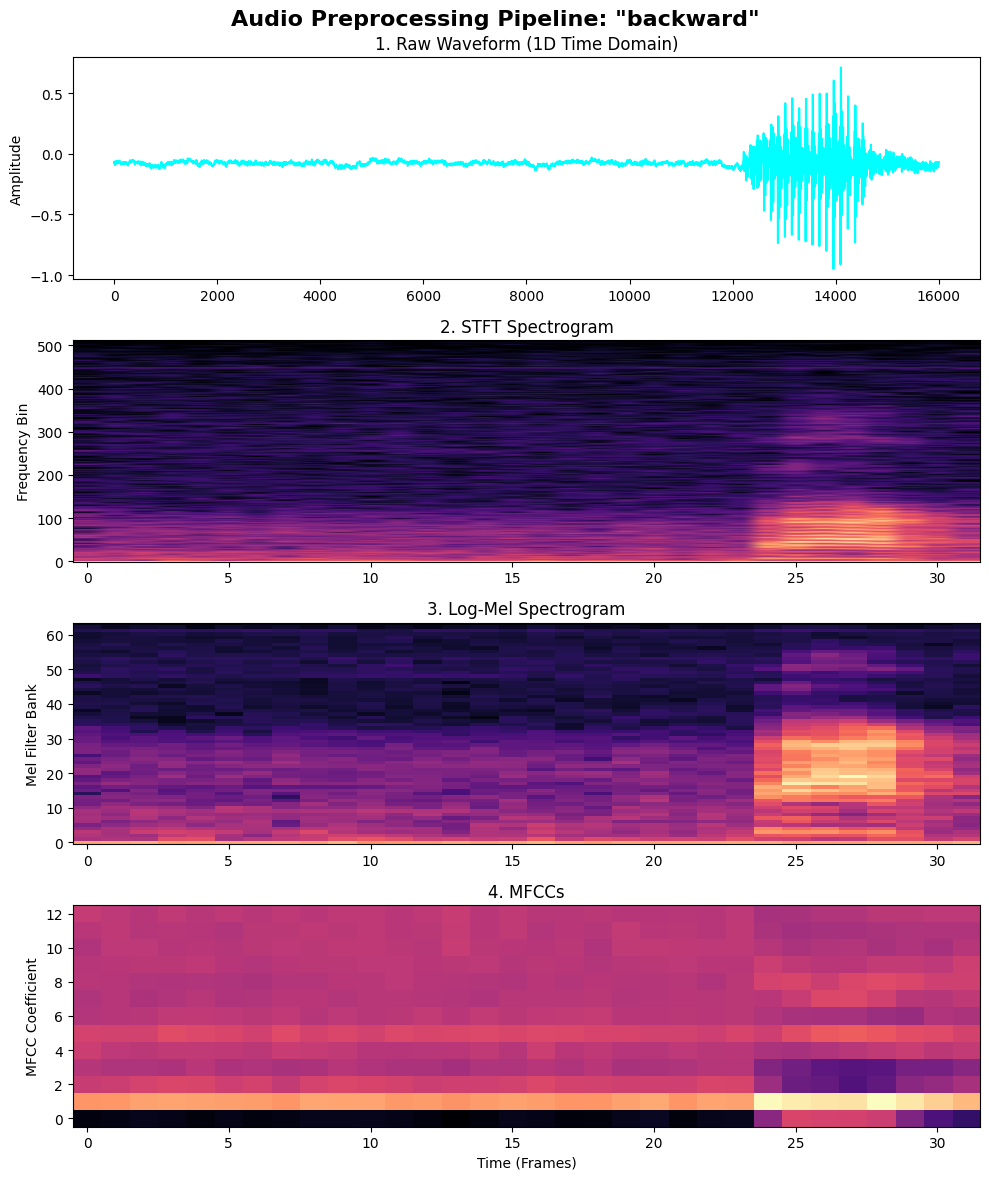

In [6]:
# Visualize Transformations by plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=False)
fig.suptitle(f'Audio Preprocessing Pipeline: "{label}"', fontsize=16, fontweight='bold')

# 1. Plot Raw Waveform
axs[0].plot(waveform[0].numpy(), color='cyan')
axs[0].set_title("1. Raw Waveform (1D Time Domain)", fontsize=12)
axs[0].set_ylabel("Amplitude")

# 2. Plot STFT Spectrogram (Log Scale)
im1 = axs[1].imshow(spec_db[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axs[1].set_title("2. STFT Spectrogram", fontsize=12)
axs[1].set_ylabel("Frequency Bin")

# 3. Plot Log-Mel Spectrogram
im2 = axs[2].imshow(log_mel_spec[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axs[2].set_title("3. Log-Mel Spectrogram", fontsize=12)
axs[2].set_ylabel("Mel Filter Bank")

# 4. Plot MFCCs
im3 = axs[3].imshow(mfcc[0].numpy(), aspect='auto', origin='lower', cmap='magma')
axs[3].set_title("4. MFCCs", fontsize=12)
axs[3].set_ylabel("MFCC Coefficient")
axs[3].set_xlabel("Time (Frames)")

plt.tight_layout()
plt.show()

After each transformation you can still see the original pattern of the raw data. However, after each one you lose more information. This will help with your compute. However, losing that information may hurt model performance so you will want to find a balance.

Now we can choose a model. The first model we will use is a CNN. Now that we know how to convert the data into 2 dimensions we can process the data similar to images.

In [7]:
# Define CNN model
class AudioCNN(nn.Module):
    def __init__(self, num_classes=35):
        super(AudioCNN, self).__init__()

        # Input: 1 channel (spectrogram), Output: 16 channels
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2) # Reduces spatial dimensions by half

        # Input: 16 channels, Output: 32 channels
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Input: 16 channels, Output: 64 channels
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification Head
        self.fc = nn.Linear(in_features=64, out_features=num_classes)

        # Dropout to prevent overfitting on smaller classes
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)

        x = torch.flatten(x, 1)
        x = self.dropout(x)

        out = self.fc(x)
        return out


The CNN architecture is 3 blocks of convolutional layer, batch normalization, and max pooling. After that it has Global Average Pooling, then a fully connected layer, and dropout.

Next we will create a label dictionary, set up the transformations on the full dataset, and create a collate function. The transformation we will be using is the log-mel spectrum. The collate function is to make sure all input is the same length (1 second).

In [8]:
# 1. Create a Label Dictionary
labels = sorted(list(set(datapoint[2] for datapoint in dataset)))
label_to_index = {label: index for index, label in enumerate(labels)}
print(f"Found {len(labels)} unique classes.")

# 2. Set up Device and Transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mel_transform = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=64).to(device)
db_transform = T.AmplitudeToDB(stype="power", top_db=80).to(device)

# 3. The Collate Function
def collate_fn(batch):
    tensors, targets = [], []

    target_length = 16000

    for waveform, _, label, *_ in batch:
        # Pad audio if it's shorter than 1 second, extend if it's longer
        if waveform.shape[1] < target_length:
            waveform = F.pad(waveform, (0, target_length - waveform.shape[1]))
        elif waveform.shape[1] > target_length:
            waveform = waveform[:, :target_length]

        # Move waveform to GPU
        waveform = waveform.to(device)

        # Calculate the Log-Mel Spectrogram
        mel_spec = mel_transform(waveform)
        log_mel = db_transform(mel_spec)

        tensors.append(log_mel)
        targets.append(label_to_index[label])

    # Stack the list of tensors into a single batch tensor
    tensors = torch.stack(tensors)
    targets = torch.tensor(targets).to(device)

    return tensors, targets

# Create the DataLoader
batch_size = 64
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

Found 35 unique classes.


There are 35 unique classes in this dataset. Next we will create a function to train our models and actaully train the model.

In [9]:
# Create Function for training model
def train_model(model, dataloader, epochs=3, lr=0.001):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (inputs, targets) in enumerate(dataloader):
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            if batch_idx % 100 == 0:
                acc = 100. * correct / total
                print(f"Epoch [{epoch+1}/{epochs}] | Batch [{batch_idx}/{len(dataloader)}] | Loss: {loss.item():.4f} | Accuracy: {acc:.2f}%")

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = 100. * correct / total
        print(f"EPOCH {epoch+1} COMPLETE | Avg Loss: {epoch_loss:.4f} | Avg Accuracy: {epoch_acc:.2f}%\n")

In [10]:
# Create model
cnn_model = AudioCNN(num_classes=len(labels))

# Train model
train_model(cnn_model, train_loader, epochs=2)

Epoch [1/2] | Batch [0/1654] | Loss: 3.8607 | Accuracy: 6.25%
Epoch [1/2] | Batch [100/1654] | Loss: 3.4600 | Accuracy: 6.19%
Epoch [1/2] | Batch [200/1654] | Loss: 3.2870 | Accuracy: 7.84%
Epoch [1/2] | Batch [300/1654] | Loss: 3.3383 | Accuracy: 9.39%
Epoch [1/2] | Batch [400/1654] | Loss: 2.8639 | Accuracy: 11.03%
Epoch [1/2] | Batch [500/1654] | Loss: 2.8734 | Accuracy: 12.60%
Epoch [1/2] | Batch [600/1654] | Loss: 2.9234 | Accuracy: 14.06%
Epoch [1/2] | Batch [700/1654] | Loss: 2.8639 | Accuracy: 15.47%
Epoch [1/2] | Batch [800/1654] | Loss: 2.5103 | Accuracy: 16.91%
Epoch [1/2] | Batch [900/1654] | Loss: 2.4947 | Accuracy: 18.21%
Epoch [1/2] | Batch [1000/1654] | Loss: 2.2248 | Accuracy: 19.41%
Epoch [1/2] | Batch [1100/1654] | Loss: 2.2485 | Accuracy: 20.59%
Epoch [1/2] | Batch [1200/1654] | Loss: 2.2665 | Accuracy: 21.71%
Epoch [1/2] | Batch [1300/1654] | Loss: 2.4592 | Accuracy: 22.72%
Epoch [1/2] | Batch [1400/1654] | Loss: 2.1562 | Accuracy: 23.73%
Epoch [1/2] | Batch [1500/

After only two epochs the average accuracy is only 48.73%. We only used 2 layers so most likely it is due to not enough feature maps. We will now try to improve it by using a CRNN.

## CRNN Model

Another common model for audio is a Convolutional Recurrent Neural Network. This is basically an RNN that takes the output of a CNN as input. We will use the same structure of the original CNN except now we will add a GRU model to the end. After the architecture is made we can establish and train the model the same way we did with the CNN.

In [11]:
class AudioCRNN(nn.Module):
    def __init__(self, num_classes=35):
        super(AudioCRNN, self).__init__()

        # CNN Part: Feature extraction from spectrograms (same as previous CNN)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # RNN Part: Process the sequence of features extracted by CNN
        self.gru = nn.GRU(input_size=64 * 16, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)

        # Classification Head
        # Bidirectional GRU output
        self.fc = nn.Linear(in_features=2 * 128, out_features=num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(x.size(0), x.size(1), -1)

        x, _ = self.gru(x)

        x = x[:, -1, :]

        x = self.dropout(x)
        out = self.fc(x)
        return out

In [12]:
# Create CRNN model
crnn_model = AudioCRNN(num_classes=len(labels))

# Train CRNN model
print("Training CRNN Model")
train_model(crnn_model, train_loader, epochs=2)

Training CRNN Model
Epoch [1/2] | Batch [0/1654] | Loss: 3.5897 | Accuracy: 1.56%
Epoch [1/2] | Batch [100/1654] | Loss: 2.0046 | Accuracy: 20.24%
Epoch [1/2] | Batch [200/1654] | Loss: 1.1563 | Accuracy: 37.13%
Epoch [1/2] | Batch [300/1654] | Loss: 1.0815 | Accuracy: 47.89%
Epoch [1/2] | Batch [400/1654] | Loss: 0.6659 | Accuracy: 54.98%
Epoch [1/2] | Batch [500/1654] | Loss: 1.1008 | Accuracy: 59.81%
Epoch [1/2] | Batch [600/1654] | Loss: 0.8023 | Accuracy: 63.39%
Epoch [1/2] | Batch [700/1654] | Loss: 0.3903 | Accuracy: 66.21%
Epoch [1/2] | Batch [800/1654] | Loss: 0.4165 | Accuracy: 68.43%
Epoch [1/2] | Batch [900/1654] | Loss: 0.7987 | Accuracy: 70.28%
Epoch [1/2] | Batch [1000/1654] | Loss: 0.5944 | Accuracy: 71.75%
Epoch [1/2] | Batch [1100/1654] | Loss: 0.4014 | Accuracy: 73.03%
Epoch [1/2] | Batch [1200/1654] | Loss: 0.7690 | Accuracy: 74.15%
Epoch [1/2] | Batch [1300/1654] | Loss: 0.4388 | Accuracy: 75.18%
Epoch [1/2] | Batch [1400/1654] | Loss: 0.4509 | Accuracy: 76.06%
Epo

This model performed much better during training! We will not use it on unseen data to see if it has really improved by that much.

## Testing the Models

The speech commands dataset has a very convinient test dataset built in so we will load and test with this data.

In [13]:
# Load test data for evaluation
test_dataset = torchaudio.datasets.SPEECHCOMMANDS(
    root="./data",
    url="speech_commands_v0.02",
    subset="testing",
    download=True
)

# Create two separate dataloaders using our two different collate functions
cnn_test_loader = DataLoader(test_dataset, batch_size=64, collate_fn=collate_fn)
crnn_test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=collate_fn)

print("Test dataset loaded: ", len(test_dataset))


Test dataset loaded:  11005


Now that we have the test data loaded we can create a function to evaluate the model

In [14]:
# Create function for Evaluation
def evaluate_model(model, dataloader, model_name, is_transformer=False):
    model.eval()
    correct = 0
    total = 0

    print(model_name)

    with torch.no_grad():
        for batch in dataloader:

            # Used to differentiate between models
            if is_transformer:
                input_values = batch['input_values'].to(device)
                targets = batch['labels'].to(device)
                outputs = model(input_values=input_values).logits
            else:
                inputs, targets = batch
                outputs = model(inputs)

            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    print(f"{model_name} Test Accuracy: {accuracy:.2f}%")
    return accuracy


In [15]:
# Evaluate the Custom CNN
cnn_accuracy = evaluate_model(cnn_model, cnn_test_loader, "CNN", is_transformer=False)


CNN
CNN Test Accuracy: 62.25%


In [16]:
# Evaluate the CRNN
crnn_accuracy = evaluate_model(crnn_model, crnn_test_loader, "CRNN", is_transformer=False)

CRNN
CRNN Test Accuracy: 94.17%


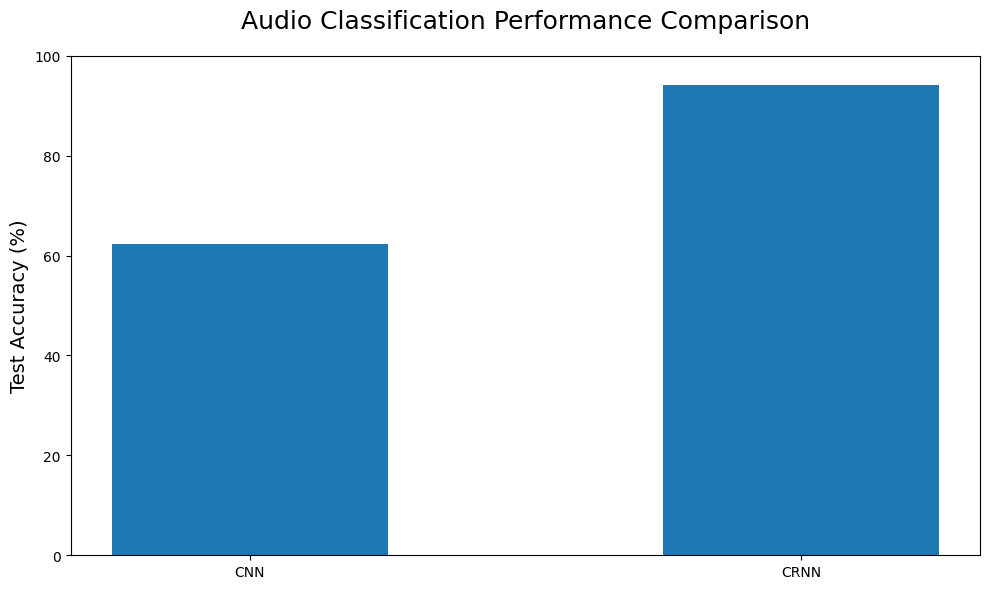

In [17]:
models = ['CNN', 'CRNN']
accuracies = [cnn_accuracy, crnn_accuracy]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(models, accuracies, width=0.5)

ax.set_ylabel('Test Accuracy (%)', fontsize=14)
ax.set_title('Audio Classification Performance Comparison',fontsize=18, pad=20)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()